In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd


from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
layout1 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250131_mACmChPOLR2A_smFISH/250131_mACmChPOLR2A_smFISH.csv")
layout1 = layout1.rename(columns = {"ATTO565 PROBE" : "ATTO565_PROBE", "ATTO633 PROBE" : "ATTO633_PROBE"})

layout2 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250404_mACmChPOLR2A_smFISH/250404_mACmChPOLR2A_smFISH.csv")
layout3 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250912_mACmChPOLR2A_smFISH/250912_mACmChPOLR2A_smFISH.csv")

## load quantification files from relevant directories, and assemble into data frames

In [3]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250131_mACmChPOLR2A_smFISH/20250204_171458_755/QUANTIFICATION/")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
len(quantification_files_1)

1006

In [4]:
quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250404_mACmChPOLR2A_smFISH/20250408_180002_502/QUANTIFICATION/")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))
len(quantification_files_2)

678

In [5]:
quantification_directory_3 = Path("//Users/alexandergillis/Desktop/KATANA_PULL/250912_mACmChPOLR2A_smFISH/20250916_165545_947/QUANTIFICATION/")
quantification_files_3 = glob.glob(str(quantification_directory_3 / "*.csv"))
len(quantification_files_3)

860

In [6]:
Nuclei_quant_files_1 = [i for i in quantification_files_1 if "nuclei_" in i]
Cell_quant_files_1 = [i for i in quantification_files_1 if "cells_" in i]

Nuclei_quant_files_2 = [i for i in quantification_files_2 if "nuclei_" in i]
Cell_quant_files_2 = [i for i in quantification_files_2 if "cells_" in i]

Nuclei_quant_files_3 = [i for i in quantification_files_3 if "nuclei_" in i]
Cell_quant_files_3 = [i for i in quantification_files_3 if "cells_" in i]

In [7]:
qdfs = list()

for f in tqdm(Cell_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_1['fov'] = fovs

quantifcation_percell_1 = quantifcation_percell_1.query('Cells_3D_is_border == False')

Quantification = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "LABEL" : quantifcation_percell_1['label'],
    "CellVolume" : quantifcation_percell_1['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_1['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_1['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_1['fov'] = fovs

QuantificationNuclei = pd.DataFrame({
    "WELL" : quantifcation_pernuc_1['well'],
    "FOV" : quantifcation_pernuc_1['fov'],
    "LABEL" : quantifcation_pernuc_1['label'],
    "NucleiVolume" : quantifcation_pernuc_1['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_405']
})

100%|███████████████████████████████████████████████████████████████| 503/503 [00:01<00:00, 252.70it/s]


In [8]:
Quantification = Quantification.merge(QuantificationNuclei, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification.dropna(inplace = True)
Quantification = Quantification.query('NucleiVolume > 0.5')
Quantification['EXPERIMENT'] = np.tile('250131', len(Quantification.index))
QuantificationNoLayout = Quantification

In [9]:
qdfs = list()

for f in tqdm(Cell_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_2['fov'] = fovs

quantifcation_percell_2 = quantifcation_percell_2.query('Cells_3D_is_border == False')

Quantification2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "LABEL" : quantifcation_percell_2['label'],
    "CellVolume" : quantifcation_percell_2['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_2['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_2['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_2['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_2['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_2['fov'] = fovs

QuantificationNuclei2 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_2['well'],
    "FOV" : quantifcation_pernuc_2['fov'],
    "LABEL" : quantifcation_pernuc_2['label'],
    "NucleiVolume" : quantifcation_pernuc_2['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_405']
})

100%|███████████████████████████████████████████████████████████████| 339/339 [00:01<00:00, 277.16it/s]


In [10]:
Quantification2 = Quantification2.merge(QuantificationNuclei2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification2.dropna(inplace = True)
Quantification2 = Quantification2.query('NucleiVolume > 0.5')
Quantification2['EXPERIMENT'] = np.tile('250404', len(Quantification2.index))
QuantificationNoLayout2 = Quantification2

In [11]:
qdfs = list()

for f in tqdm(Cell_quant_files_3):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_3 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_3['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_3['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_3['fov'] = fovs

quantifcation_percell_3 = quantifcation_percell_3.query('Cells_3D_is_border == False')

Quantification3 = pd.DataFrame({
    "WELL" : quantifcation_percell_3['well'],
    "FOV" : quantifcation_percell_3['fov'],
    "LABEL" : quantifcation_percell_3['label'],
    "CellVolume" : quantifcation_percell_3['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_3['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_3['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_3):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_3 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_3['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_3['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_3['fov'] = fovs

QuantificationNuclei3 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_3['well'],
    "FOV" : quantifcation_pernuc_3['fov'],
    "LABEL" : quantifcation_pernuc_3['label'],
    "NucleiVolume" : quantifcation_pernuc_3['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_3['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_3['Nuclei_3D_intensity_mean_405']
})

100%|███████████████████████████████████████████████████████████████| 430/430 [00:01<00:00, 254.51it/s]


In [12]:
Quantification3 = Quantification3.merge(QuantificationNuclei3, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification3.dropna(inplace = True)
Quantification3 = Quantification3.query('NucleiVolume > 0.5')
Quantification3['EXPERIMENT'] = np.tile('250912', len(Quantification3.index))
QuantificationNoLayout3 = Quantification3

In [13]:
Quantification = Quantification.merge(layout1, how = 'left', left_on = "WELL", right_on = "WELL")
Quantification2 = Quantification2.merge(layout2, how = 'left', left_on = "WELL", right_on = "WELL")
Quantification3 = Quantification3.merge(layout3, how = 'left', left_on = "WELL", right_on = "WELL")

In [14]:
QuantificationMultiple = pd.concat([Quantification, Quantification2, Quantification3])

In [15]:
QuantificationMultiple.groupby(['EXPERIMENT', 'WELL', 'CELL', 'TREATMENT']).count()

FOV  LABEL  CellVolume  \
EXPERIMENT WELL   CELL          TREATMENT                              
250131     Well02 OsTIRF74G     Vehicle       680    680         680   
           Well03 OsTIRF74G     5PhIAA        442    442         442   
           Well04 mACPOLR2A     Vehicle       376    376         376   
           Well05 mACPOLR2A     5PhIAA        281    281         281   
           Well07 OsTIRF74G     No treatment  677    677         677   
           Well08 OsTIRF74G     No treatment  686    686         686   
           Well09 OsTIRF74G     No treatment  743    743         743   
           Well10 mChPOLR2A     Vehicle       864    864         864   
           Well11 mChPOLR2A     5PhIAA        749    749         749   
           Well12 OsTIRF74G     No treatment  521    521         521   
           Well14 OsTIRF74G     No treatment  512    512         512   
           Well15 OsTIRF74G     No treatment  584    584         584   
           Well16 mAC/mChPOLR2A Vehicle       275    275         275   
           Well17 mAC/mChPOLR2A 5PhIAA        235    235         235   
250404     Well02 OsTIRF74G     Vehicle       292    292         292   
           Well03 mChPOLR2A     Vehicle       227    227         227   
           Well04 mACPOLR2A     Vehicle       198    198         198   
           Well05 mAC/mChPOLR2A Vehicle       156    156         156   
           Well07 OsTIRF74G     5PhIAA        237    237         237   
           Well08 OsTIRF74G     5PhIAA        334    334         334   
           Well09 mChPOLR2A     5PhIAA        100    100         100   
           Well10 mACPOLR2A     5PhIAA        171    171         171   
           Well11 mAC/mChPOLR2A 5PhIAA        135    135         135   
           Well12 mACPOLR2A     Vehicle       363    363         363   
           Well14 OsTIRF74G     5PhIAA        508    508         508   
           Well15 mACPOLR2A     5PhIAA        148    148         148   
           Well16 mACPOLR2A     Vehicle       268    268         268   
           Well17 mACPOLR2A     5PhIAA        210    210         210   
250912     Well01 OsTIRF74G     Vehicle       314    314         314   
           Well02 OsTIRF74G     Vehicle       150    150         150   
           Well03 mChPOLR2A     Vehicle       247    247         247   
           Well04 mAC/mChPOLR2A Vehicle        43     43          43   
           Well05 mACPOLR2A     Vehicle       196    196         196   
           Well06 OsTIRF74G     Vehicle       184    184         184   
           Well07 OsTIRF74G     Vehicle       252    252         252   
           Well08 OsTIRF74G     5PhIAA        219    219         219   
           Well09 mChPOLR2A     5PhIAA        139    139         139   
           Well10 mAC/mChPOLR2A 5PhIAA         56     56          56   
           Well11 mACPOLR2A     5PhIAA        165    165         165   
           Well12 mACPOLR2A     Vehicle       306    306         306   
           Well13 OsTIRF74G     LMB            66     66          66   
           Well14 mChPOLR2A     LMB            85     85          85   
           Well15 mChPOLR2A     CB6644         67     67          67   
           Well16 OsTIRF74G     5PhIAA        348    348         348   
           Well17 mACPOLR2A     5PhIAA        114    114         114   
           Well18 OsTIRF74G     CB6644         83     83          83   

                                              Spots_565  Spots_633  \
EXPERIMENT WELL   CELL          TREATMENT                            
250131     Well02 OsTIRF74G     Vehicle             680        680   
           Well03 OsTIRF74G     5PhIAA              442        442   
           Well04 mACPOLR2A     Vehicle             376        376   
           Well05 mACPOLR2A     5PhIAA              281        281   
           Well07 OsTIRF74G     No treatment        677        677   
           Well08 OsTIRF74G     No treatment        686        686   
           Well09 OsTIRF74G  

## check nuclei intensities

In [16]:
QuantificationMultiple.columns.tolist()

['WELL',
 'FOV',
 'LABEL',
 'CellVolume',
 'Spots_565',
 'Spots_633',
 'NucleiVolume',
 'Nuclei561Mean',
 'Nuclei405Mean',
 'EXPERIMENT',
 'ATTO565_PROBE',
 'ATTO633_PROBE',
 'CELL',
 'TREATMENT']

In [17]:
WellMeans = QuantificationMultiple.drop(['FOV','LABEL'],axis = 1).groupby(['WELL','ATTO565_PROBE','ATTO633_PROBE','CELL', 'TREATMENT','EXPERIMENT']).mean().reset_index()

In [18]:
QuantificationMultiple.CELL.unique()

array(['OsTIRF74G', 'mChPOLR2A', 'mAC/mChPOLR2A', 'mACPOLR2A'],
      dtype=object)

In [19]:
cell_order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A']

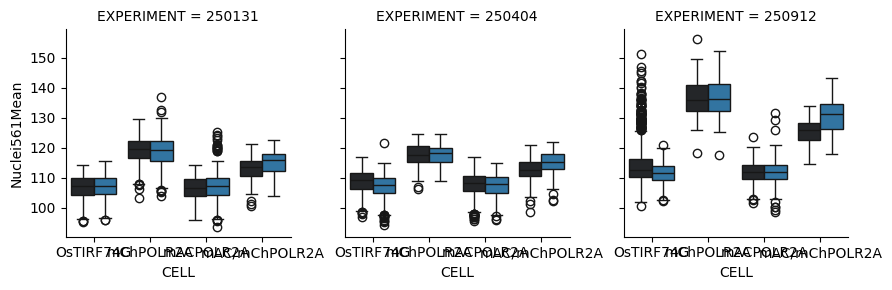

In [20]:
g = sns.FacetGrid(QuantificationMultiple, col = 'EXPERIMENT')

g.map_dataframe(sns.boxplot, 
                x = 'CELL', order = cell_order,
                y = 'Nuclei561Mean', 
                hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA'])

Text(0, 0.5, 'POLR2A spots per cell')

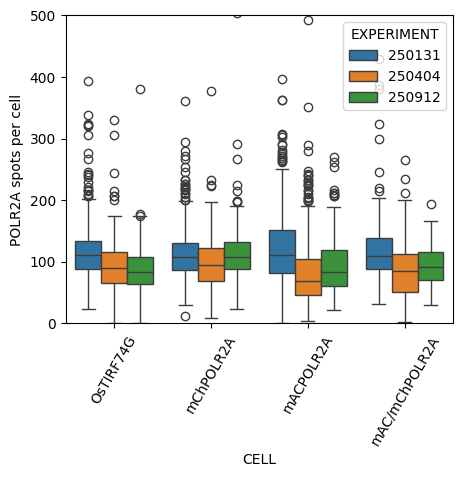

In [21]:
f, a = plt.subplots( figsize = (5,4) )

sns.boxplot(QuantificationMultiple.query('TREATMENT == "Vehicle" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'), 
            x = 'CELL', order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A'],
            y = 'Spots_633',
           hue = 'EXPERIMENT')
plt.ylim(0,500)

plt.xticks(rotation = 60)

plt.ylabel('POLR2A spots per cell')

Text(0, 0.5, 'Volume_pL')

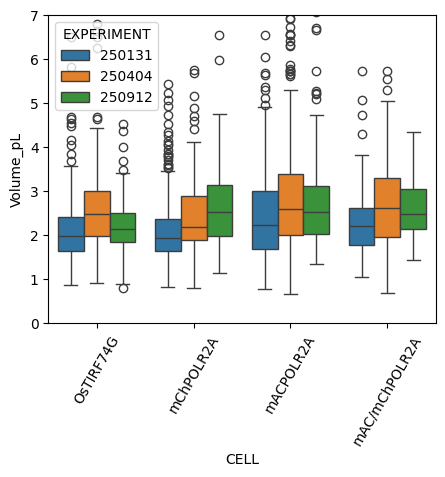

In [22]:
f, a = plt.subplots( figsize = (5,4) )

sns.boxplot(QuantificationMultiple.query('TREATMENT == "Vehicle" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'), 
            x = 'CELL', order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A'],
            y = 'CellVolume',
           hue = 'EXPERIMENT')
plt.ylim(0,7)

plt.xticks(rotation = 60)

plt.ylabel('Volume_pL')

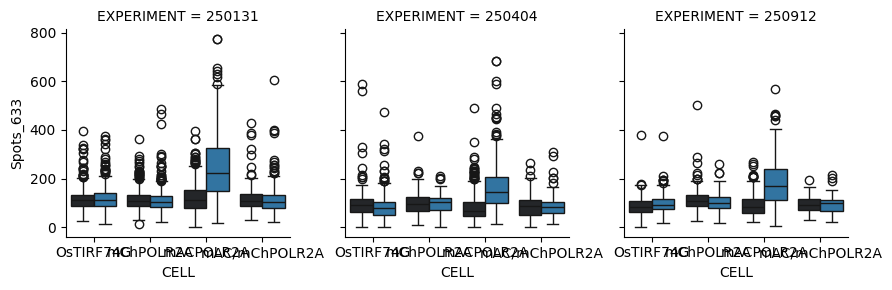

In [23]:
g = sns.FacetGrid(QuantificationMultiple.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.boxplot,
                x = 'CELL', order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A'],
                y = 'Spots_633',
                hue = 'TREATMENT', hue_order = ['Vehicle', '5PhIAA'])

(0.0, 300.0)

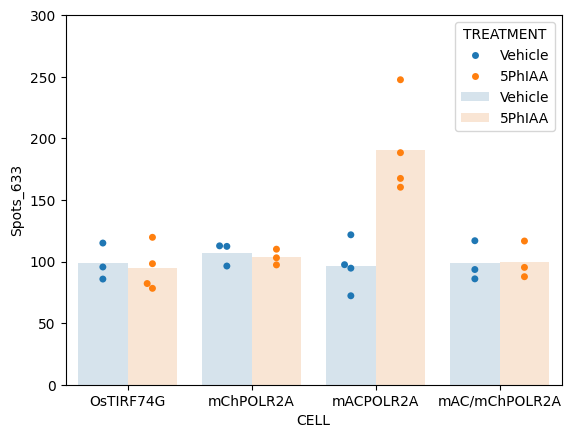

In [24]:
sns.swarmplot(WellMeans.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'),
              x = 'CELL', order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A'],
              y = 'Spots_633',
              hue = 'TREATMENT', dodge = True, hue_order = ['Vehicle', '5PhIAA'])

sns.barplot(WellMeans.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'),
              x = 'CELL', order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A'],
              y = 'Spots_633',
              hue = 'TREATMENT', dodge = True, hue_order = ['Vehicle', '5PhIAA'],
              alpha = 0.2, errorbar = None)

plt.ylim(0,300)

In [25]:
Experiment_Means_PolII = WellMeans.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")').drop(['WELL','ATTO565_PROBE','ATTO633_PROBE'],axis=1).groupby(['CELL','TREATMENT','EXPERIMENT']).mean().reset_index()

In [26]:
Experiment_Means_PolII = Experiment_Means_PolII.query('TREATMENT != "No treatment"')

In [27]:
l1 = Experiment_Means_PolII.CELL.unique()
l2 = ['TIR','mACmCh','mAC','mCh']
Experiment_Means_PolII['CELL_TYPE'] = Experiment_Means_PolII.CELL.map(dict(zip(l1,l2)))

(0.0, 260.0)

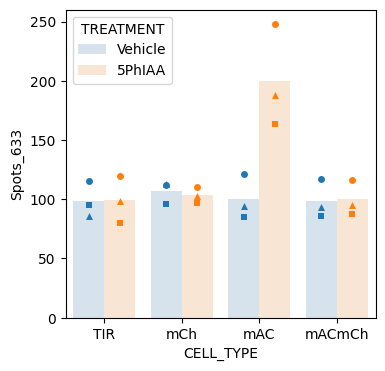

In [28]:
f, a = plt.subplots(figsize = (4,4))

sns.swarmplot(Experiment_Means_PolII.query('EXPERIMENT == "250131"'),
              x = 'CELL_TYPE', order = ['TIR','mCh','mAC','mACmCh'],
              y = 'Spots_633',
              hue = 'TREATMENT', dodge = True, hue_order = ['Vehicle', '5PhIAA'],
             legend = False)

sns.swarmplot(Experiment_Means_PolII.query('EXPERIMENT == "250404"'),
              x = 'CELL_TYPE', order = ['TIR','mCh','mAC','mACmCh'],
              y = 'Spots_633',
              hue = 'TREATMENT', dodge = True, hue_order = ['Vehicle', '5PhIAA'],
              marker = 's',
             legend = False)

sns.swarmplot(Experiment_Means_PolII.query('EXPERIMENT == "250912"'),
              x = 'CELL_TYPE', order = ['TIR','mCh','mAC','mACmCh'],
              y = 'Spots_633',
              hue = 'TREATMENT', dodge = True, hue_order = ['Vehicle', '5PhIAA'],
              marker = '^',
             legend = False)

sns.barplot(Experiment_Means_PolII,
              x = 'CELL_TYPE', order = ['TIR','mCh','mAC','mACmCh'],
              y = 'Spots_633',
              hue = 'TREATMENT', dodge = True, hue_order = ['Vehicle', '5PhIAA'],
              errorbar = None, alpha = 0.2)

plt.ylim(0,260)

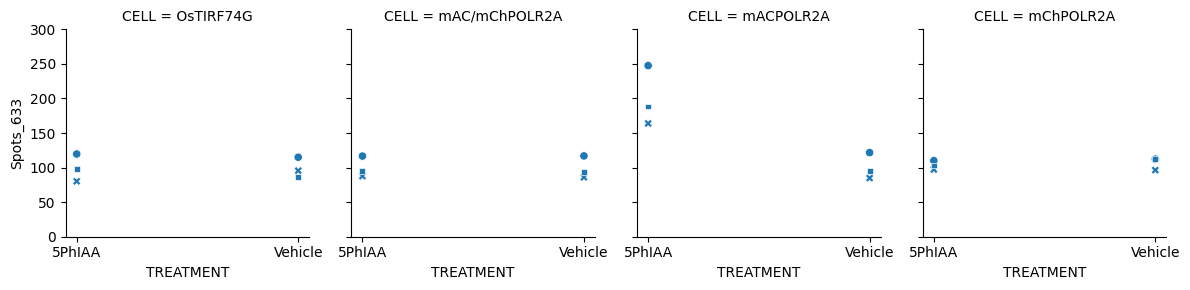

In [29]:
g = sns.FacetGrid(Experiment_Means_PolII.query('TREATMENT == "Vehicle" | TREATMENT == "5PhIAA" '),
                  col = 'CELL',
                 ylim = (0,300))

g.map_dataframe(sns.scatterplot, 
                x = 'TREATMENT',
                y = 'Spots_633',
                style = 'EXPERIMENT')

TypeError: seaborn.utils._scatter_legend_artist() got multiple values for keyword argument 'label'

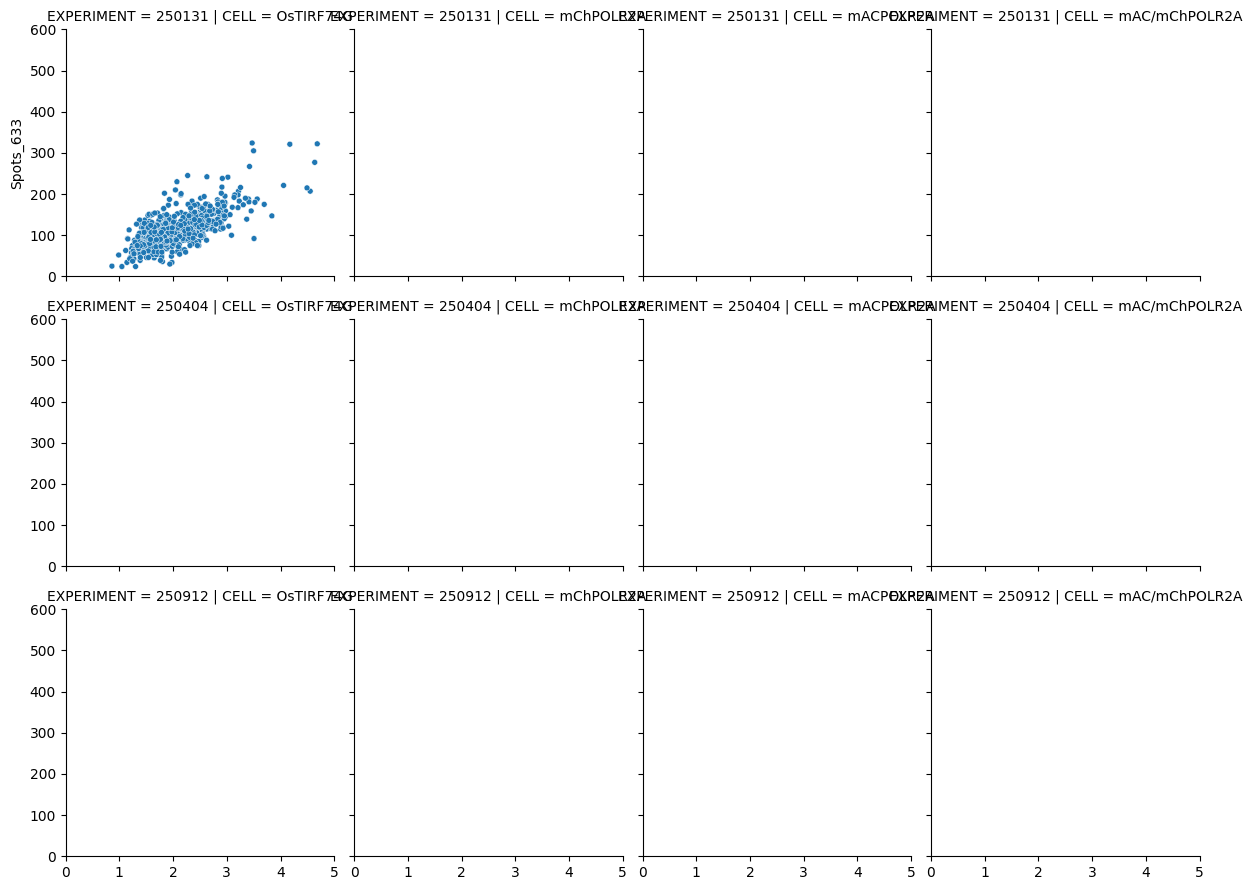

In [30]:
g = sns.FacetGrid(QuantificationMultiple.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'),
                  col = 'CELL', col_order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A'],
                  row = 'EXPERIMENT',
                  hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
                 aspect = 1,
                 xlim = (0,5),
                 ylim = (0,600))

g.map_dataframe(sns.scatterplot, x = 'CellVolume', y = 'Spots_633', size = 4)
g.set_ylabels('POLR2A spots per cell')
g.set_xlabels('Volume_pL')

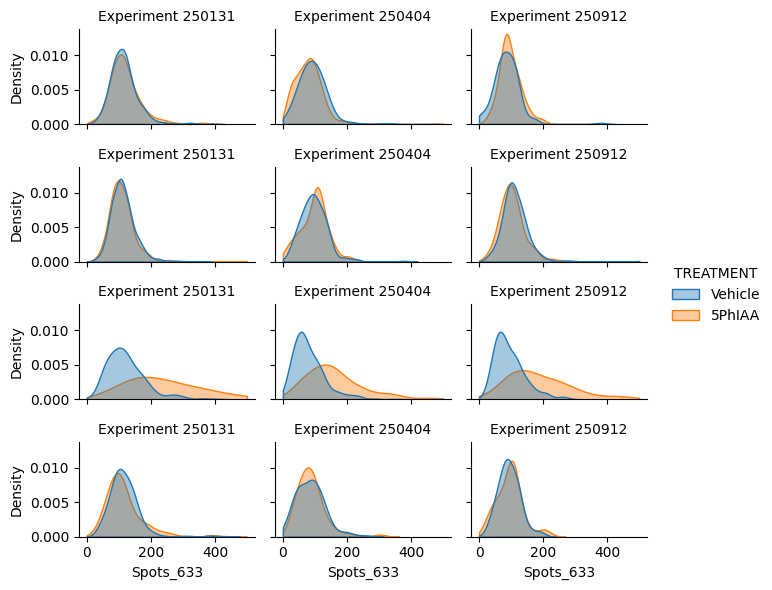

In [31]:
g = sns.displot(QuantificationMultiple.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'), 
            row = 'CELL', row_order = ['OsTIRF74G', 'mChPOLR2A', 'mACPOLR2A','mAC/mChPOLR2A'],
            col = 'EXPERIMENT',
            hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
            x='Spots_633', 
            kind='kde', 
            clip = (0,500),
           aspect = 1.5, height = 1.5,
           common_norm = False,
           fill = True, alpha = 0.4)

g.set_titles("Experiment {col_name}")

In [32]:
l1 = QuantificationMultiple.CELL.unique()
l2 = ['mCh/mCh', 'mAC/mAC', 'mAC/mCh','Parental']
QuantificationMultiple['CELL_TYPE'] = QuantificationMultiple.CELL.map(dict(zip(l1,l2)))

In [33]:
QuantificationMultiple['REPLICATE'] = QuantificationMultiple.EXPERIMENT.map({'250131' : 'Replicate 1','250404' : 'Replicate 2','250912' : 'Replicate 3'})

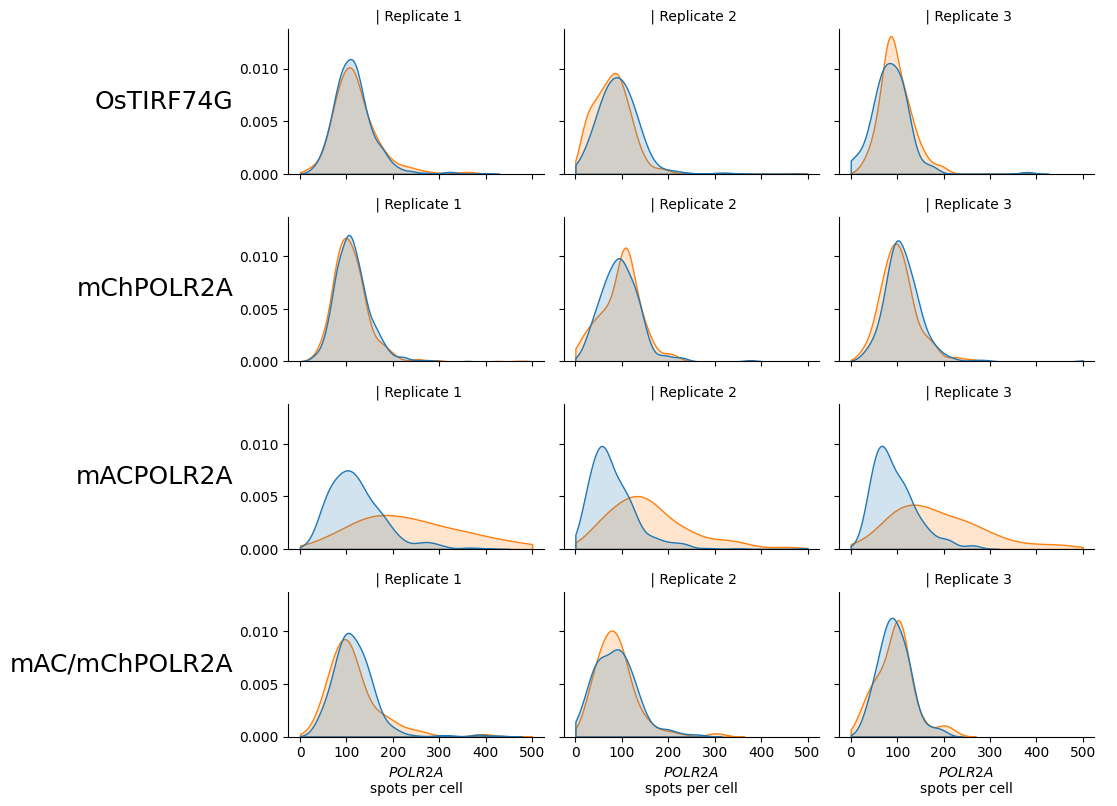

In [34]:
g = sns.FacetGrid(QuantificationMultiple.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'), 
            row = 'CELL', row_order = ['OsTIRF74G','mChPOLR2A','mACPOLR2A', 'mAC/mChPOLR2A'],
            col = 'REPLICATE',
                  aspect = 1.5, height = 2)

g.map_dataframe(sns.kdeplot,
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
                x='Spots_633', 
                clip = (0,500),
                common_norm = False,
                fill = True, alpha = 0.2)

g.set_titles(col_template="{col_name}", row_template="")
g.set_xlabels(label = '$POLR2A$ \nspots per cell')
g.add_legend()

for ax,l in zip(g.axes[:,0],['OsTIRF74G','mChPOLR2A','mACPOLR2A', 'mAC/mChPOLR2A']):
    ax.set_ylabel(l, fontsize=18, rotation=0, ha='right', va='center')

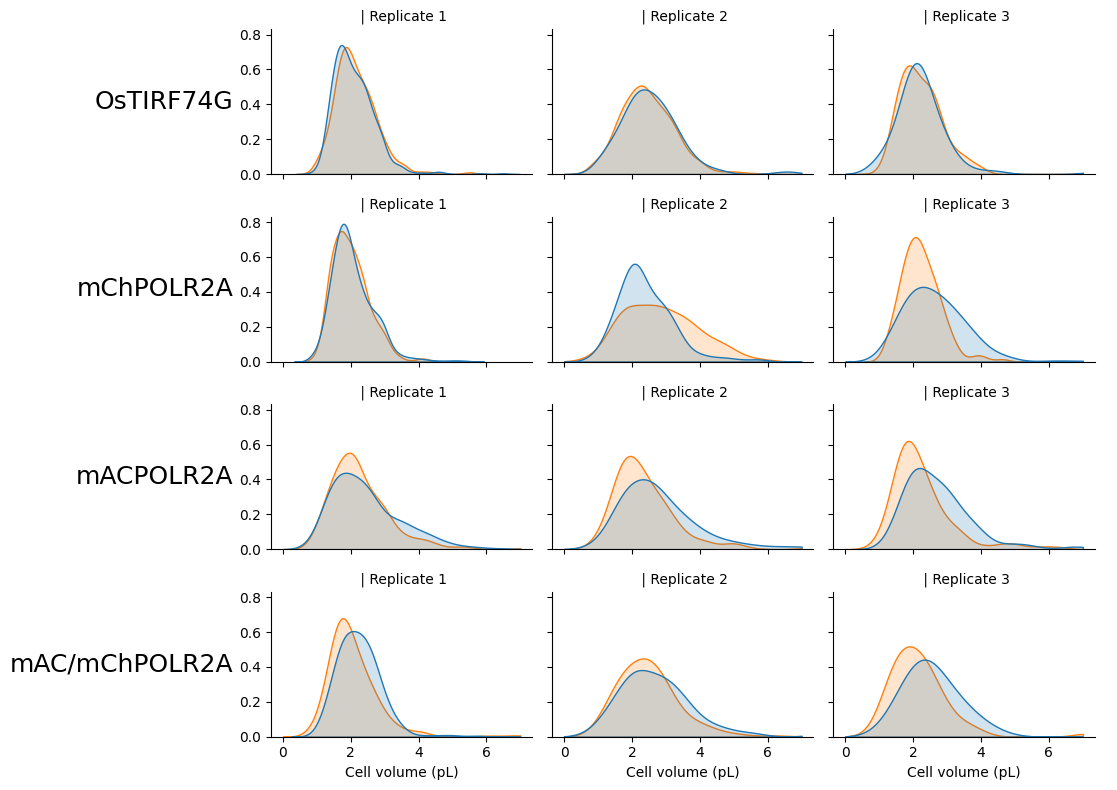

In [35]:
g = sns.FacetGrid(QuantificationMultiple.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")'), 
            row = 'CELL', row_order = ['OsTIRF74G','mChPOLR2A','mACPOLR2A', 'mAC/mChPOLR2A'],
            col = 'REPLICATE',
                  aspect = 1.5, height = 2)

g.map_dataframe(sns.kdeplot,
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
                x='CellVolume', 
                clip = (0,7),
                common_norm = False,
                fill = True, alpha = 0.2)

g.set_titles(col_template="{col_name}", row_template="")
g.set_xlabels(label = 'Cell volume (pL)')
g.add_legend()

for ax,l in zip(g.axes[:,0],['OsTIRF74G','mChPOLR2A','mACPOLR2A', 'mAC/mChPOLR2A']):
    ax.set_ylabel(l, fontsize=18, rotation=0, ha='right', va='center')

## plot mACmCh vs parental for talk

In [36]:
PlotForTalk = QuantificationMultiple.query('TREATMENT != "No addition" & (ATTO633_PROBE == "POLR2A exon" | ATTO633_PROBE == "POLR2A even")')

In [37]:
PlotForTalk['REPLICATE'] = PlotForTalk.EXPERIMENT.map({'250131' : 'Replicate 1','250404' : 'Replicate 2','250912' : 'Replicate 3'})

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_80639/3893384006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PlotForTalk['REPLICATE'] = PlotForTalk.EXPERIMENT.map({'250131' : 'Replicate 1','250404' : 'Replicate 2','250912' : 'Replicate 3'})


In [38]:
PlotForTalk.REPLICATE.unique()

array(['Replicate 1', 'Replicate 2', 'Replicate 3'], dtype=object)

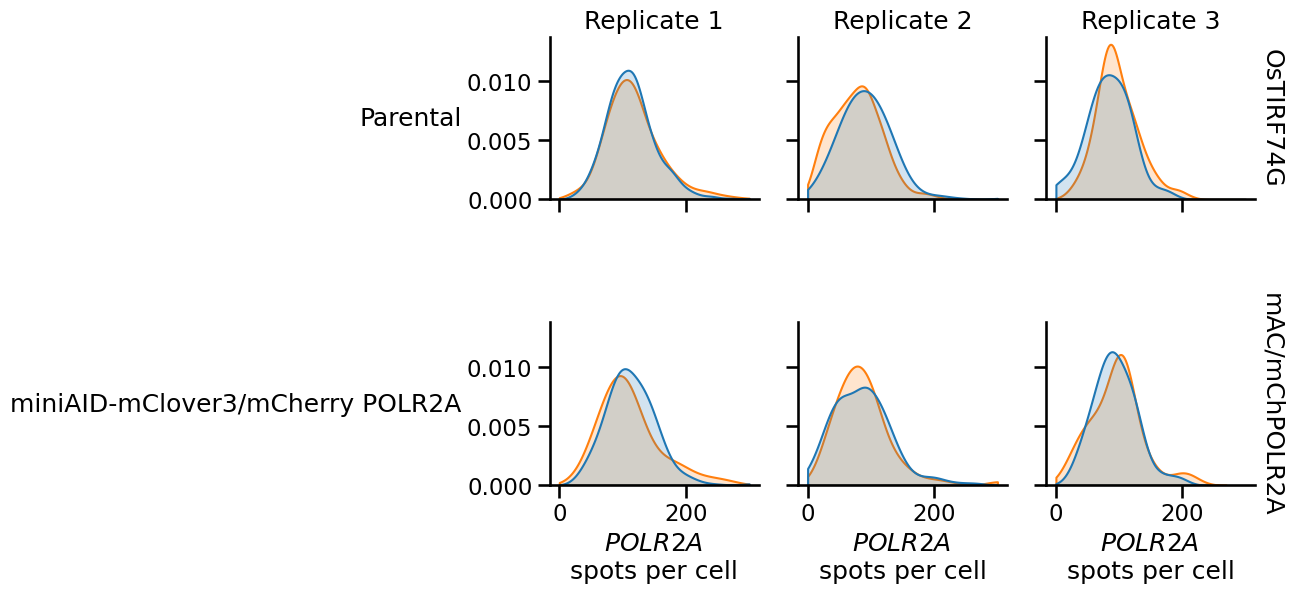

In [39]:
sns.set_context('talk')

g = sns.FacetGrid(PlotForTalk, 
            row = 'CELL', row_order = ['OsTIRF74G','mAC/mChPOLR2A'],
            col = 'REPLICATE',
                  aspect = 1, height = 3,
                  legend_out = True,
                 margin_titles = True)

g.map_dataframe(sns.kdeplot,
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
                x='Spots_633', 
                clip = (0,300),
                common_norm = False,
                fill = True, alpha = 0.2,
               legend = True)

for ax,l in zip(g.axes[:,0],['Parental','miniAID-mClover3/mCherry POLR2A']):
    ax.set_ylabel(l, fontsize=18, rotation=0, ha='right', va='center')

g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xlabels(label = '$POLR2A$ \nspots per cell')

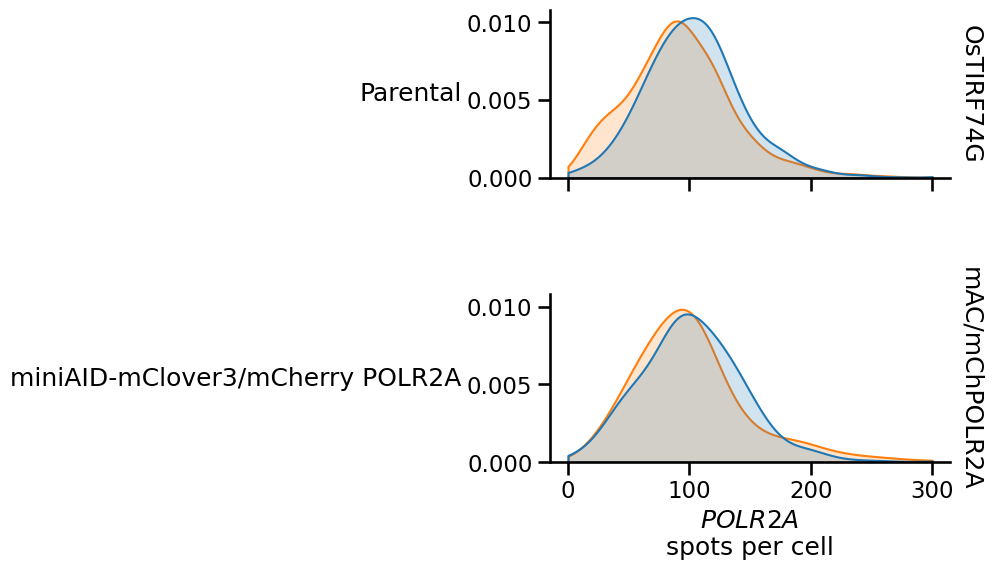

In [40]:
sns.set_context('talk')

g = sns.FacetGrid(PlotForTalk, 
            row = 'CELL', row_order = ['OsTIRF74G','mAC/mChPOLR2A'],
                  aspect = 2, height = 3,
                  legend_out = True,
                 margin_titles = True)

g.map_dataframe(sns.kdeplot,
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
                x='Spots_633', 
                clip = (0,300),
                common_norm = False,
                fill = True, alpha = 0.2,
               legend = True)

for ax,l in zip(g.axes[:,0],['Parental','miniAID-mClover3/mCherry POLR2A']):
    ax.set_ylabel(l, fontsize=18, rotation=0, ha='right', va='center')

g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xlabels(label = '$POLR2A$ \nspots per cell')

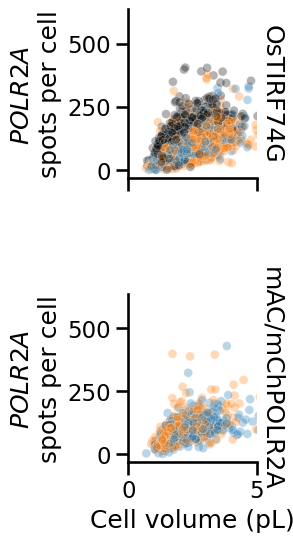

In [41]:
sns.set_context('talk')
a
g = sns.FacetGrid(PlotForTalk, 
            row = 'CELL', row_order = ['OsTIRF74G','mAC/mChPOLR2A'],
                  aspect = 1, height = 3,
                  legend_out = True,
                  xlim = (0,5),
                 margin_titles = True)

g.map_dataframe(sns.scatterplot,
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
                x = 'CellVolume',
                y='Spots_633',
                size = 2,
                alpha = 0.3)



g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xlabels(label = 'Cell volume (pL)')
g.set_ylabels(label = '$POLR2A$ \nspots per cell')

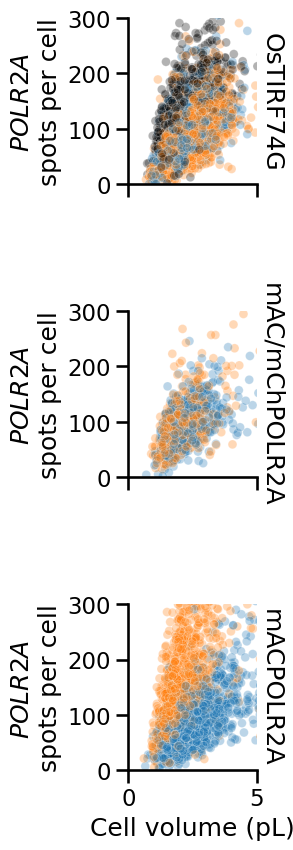

In [42]:
sns.set_context('talk')
a
g = sns.FacetGrid(PlotForTalk, 
            row = 'CELL', row_order = ['OsTIRF74G','mAC/mChPOLR2A','mACPOLR2A'],
                  aspect = 1, height = 3,
                  legend_out = True,
                  xlim = (0,5),
                  ylim = (0,300),
                 margin_titles = True)

g.map_dataframe(sns.scatterplot,
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
                x = 'CellVolume',
                y='Spots_633',
                size = 1,
                alpha = 0.3)



g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xlabels(label = 'Cell volume (pL)')
g.set_ylabels(label = '$POLR2A$ \nspots per cell')

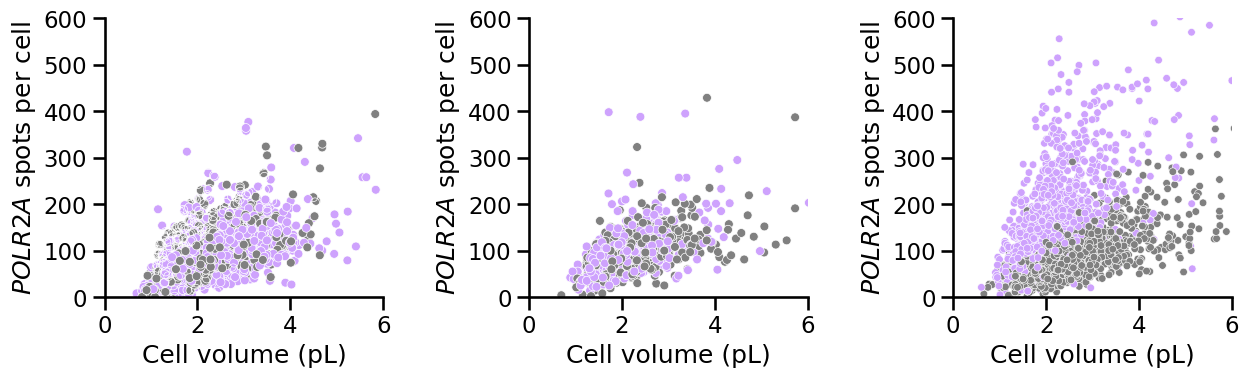

In [43]:
f, a = plt.subplots(ncols = 3, figsize = (13,4))

sns.set_context('talk')

pl = sns.color_palette(['grey', 'xkcd:lilac'])

h = sns.scatterplot(PlotForTalk.query('CELL == "OsTIRF74G" & TREATMENT != "No treatment"'),
                x = 'CellVolume',
                y='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                size = 30,
                #alpha = 0.2,
                ax = a[0],
                legend = False)

h = sns.scatterplot(PlotForTalk.query('CELL == "mAC/mChPOLR2A" & TREATMENT != "No treatment"'),
                x = 'CellVolume',
                y='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                size = 30,
                #alpha = 0.2,
                ax = a[1],
                legend = False)

h = sns.scatterplot(PlotForTalk.query('CELL == "mACPOLR2A" & TREATMENT != "No treatment"'),
                x = 'CellVolume',
                y='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                s = 30,
                #alpha = 0.2,
                ax = a[2],
                legend = False)

for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,6)
    a[i].set_ylim(0,600)
    a[i].set_ylabel('$POLR2A$ spots per cell')
    a[i].set_xlabel('Cell volume (pL)')
    
sns.despine()
plt.tight_layout()

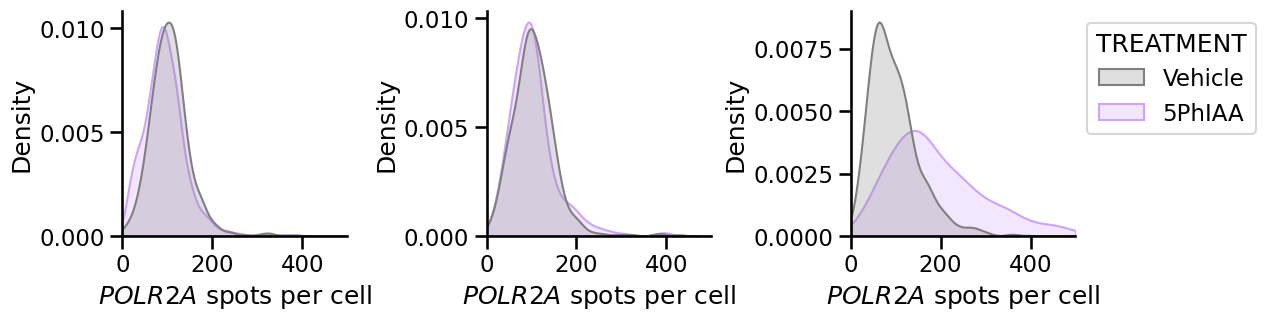

In [44]:
f, a = plt.subplots(ncols = 3, figsize = (13,4))

sns.set_context('talk')

pl = sns.color_palette(['grey', 'xkcd:lilac'])

h = sns.kdeplot(PlotForTalk.query('CELL == "OsTIRF74G" & TREATMENT != "No treatment"'),
                x='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                ax = a[0],
                fill = True,
                clip = (0,500),
                legend = False,
                common_norm = False)

h = sns.kdeplot(PlotForTalk.query('CELL == "mAC/mChPOLR2A" & TREATMENT != "No treatment"'),

                x ='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                ax = a[1],
                fill = True,
                clip = (0,500),
                common_norm = False,
                legend = False)

h = sns.kdeplot(PlotForTalk.query('CELL == "mACPOLR2A" & TREATMENT != "No treatment"'),
                x ='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                ax = a[2],
                fill = True,
                clip = (0,500),
                common_norm = False)
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,500)
    a[i].set_xlabel('$POLR2A$ spots per cell')

sns.despine()
plt.tight_layout()

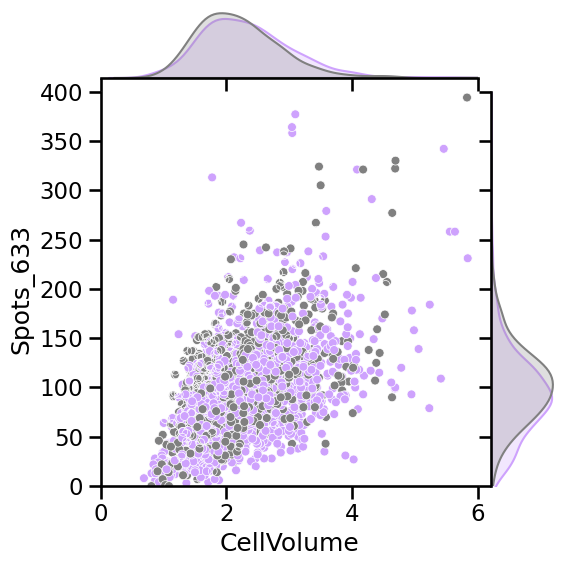

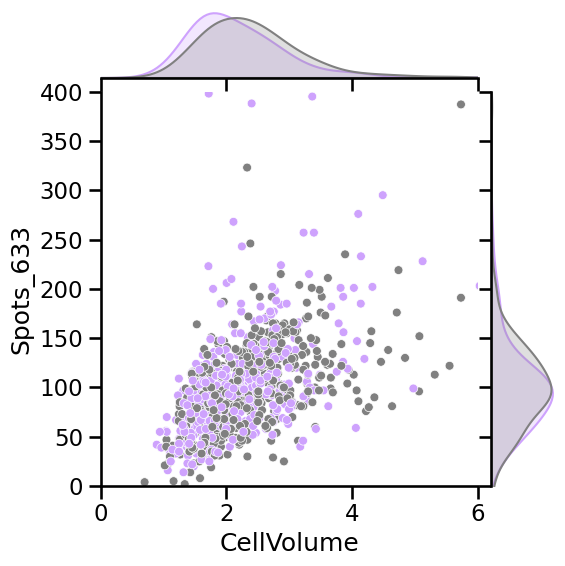

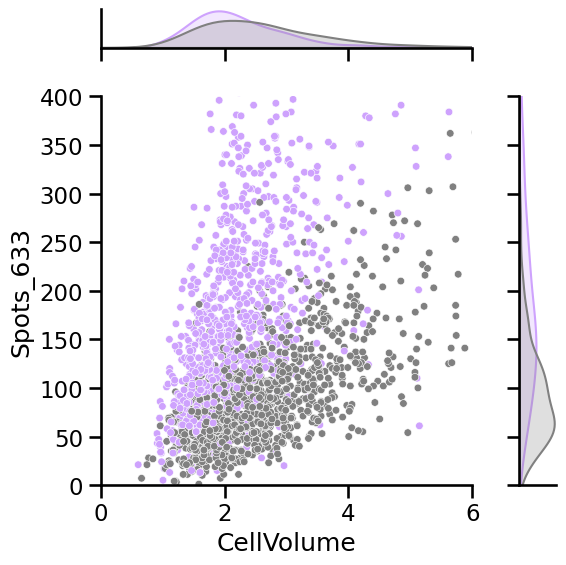

In [45]:


sns.set_context('talk')

pl = sns.color_palette(['grey', 'xkcd:lilac'])

sns.jointplot(PlotForTalk.query('CELL == "OsTIRF74G" & TREATMENT != "No treatment"'),
                x = 'CellVolume',
                y='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                size = 30,
                legend = False,
                  ylim = (0,400),
                  xlim = (0,6), marginal_kws={'common_norm': False})

h = sns.jointplot(PlotForTalk.query('CELL == "mAC/mChPOLR2A" & TREATMENT != "No treatment"'),
                x = 'CellVolume',
                y='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                size = 30,
                legend = False,
                  ylim = (0,400),
                  xlim = (0,6), marginal_kws={'common_norm': False})

h = sns.jointplot(PlotForTalk.query('CELL == "mACPOLR2A" & TREATMENT != "No treatment"'),
                x = 'CellVolume',
                y='Spots_633',
                hue='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                s = 30,
                legend = False,
                  ylim = (0,400),
                  xlim = (0,6), marginal_kws={'common_norm': False})

    
sns.despine()
plt.tight_layout()

In [46]:
binz = [p/100 for p in range(80,560,80)]
binz_centre = []
for i,b in enumerate(binz[:-1]):
    g = (binz[i+1] - b)
    h = b + g/2
    binz_centre.append(h)

In [47]:
pl = sns.color_palette(['xkcd:dark grey', 'xkcd:dark sky blue'])

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashi

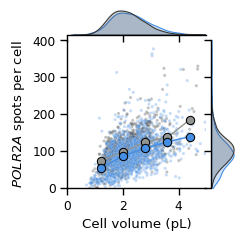

In [48]:
TIR_VEH = PlotForTalk.query('CELL == "OsTIRF74G" & TREATMENT == "Vehicle" & (ATTO633_PROBE	== "POLR2A exon" | ATTO633_PROBE == "POLR2A even")')
TIR_VEH_MEAN = TIR_VEH[['CellVolume','Spots_633']].groupby(pd.cut(TIR_VEH.CellVolume, binz)).mean()
TIR_VEH_STD = TIR_VEH[['CellVolume','Spots_633']].groupby(pd.cut(TIR_VEH.CellVolume, binz)).std()

TIR_5PH = PlotForTalk.query('CELL == "OsTIRF74G" & TREATMENT == "5PhIAA" & (ATTO633_PROBE	== "POLR2A exon" | ATTO633_PROBE == "POLR2A even")')
TIR_5PH_MEAN = TIR_5PH[['CellVolume','Spots_633']].groupby(pd.cut(TIR_5PH.CellVolume, binz)).mean()
TIR_5PH_STD = TIR_5PH[['CellVolume','Spots_633']].groupby(pd.cut(TIR_5PH.CellVolume, binz)).std()

sns.set_context('paper')




sns.jointplot(pd.concat([TIR_VEH, TIR_5PH]),
                x = 'CellVolume',
                y ='Spots_633',
                hue ='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                s = 5,
                legend = False,
                  ylim = (0,400),
                  xlim = (0,5), marginal_kws={'common_norm': False},
              height = 2.5,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = TIR_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'xkcd:grey')

sns.lineplot(x = binz_centre,
             y = TIR_5PH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'xkcd:dark sky blue')

plt.xlabel('Cell volume (pL)')
plt.ylabel('$POLR2A$ spots per cell')

plt.savefig('TIR_POLR2A_SMFISH.svg')

In [49]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:17

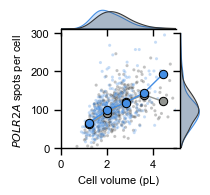

In [50]:
MACMCH_VEH = PlotForTalk.query('CELL == "mAC/mChPOLR2A" & TREATMENT == "Vehicle" & (ATTO633_PROBE	== "POLR2A exon" | ATTO633_PROBE == "POLR2A even")')
MACMCH_VEH_MEAN = MACMCH_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MACMCH_VEH.CellVolume, binz)).mean()
MACMCH_VEH_STD = MACMCH_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MACMCH_VEH.CellVolume, binz)).std()

MACMCH_5PH = PlotForTalk.query('CELL == "mAC/mChPOLR2A" & TREATMENT == "5PhIAA" & (ATTO633_PROBE	== "POLR2A exon" | ATTO633_PROBE == "POLR2A even")')
MACMCH_5PH_MEAN = MACMCH_5PH[['CellVolume','Spots_633']].groupby(pd.cut(MACMCH_5PH.CellVolume, binz)).mean()
MACMCH_5PH_STD = MACMCH_5PH[['CellVolume','Spots_633']].groupby(pd.cut(MACMCH_5PH.CellVolume, binz)).std()

sns.set_context('paper')

sns.jointplot(pd.concat([MACMCH_VEH, MACMCH_5PH]),
                x = 'CellVolume',
                y ='Spots_633',
                hue ='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = pl,
                s = 5,
                legend = False,
                  ylim = (0,300),
                  xlim = (0,5), marginal_kws={'common_norm': False},
              height = 1.8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MACMCH_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'xkcd:grey')

sns.lineplot(x = binz_centre,
             y = MACMCH_5PH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'xkcd:dark sky blue')

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2A$ spots per cell', fontsize = 8)
plt.tick_params(axis='both', labelsize=8)

plt.savefig('MACMCH_POLR2A_SMFISH.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:17

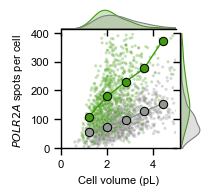

In [51]:
MAC_VEH = PlotForTalk.query('CELL == "mACPOLR2A" & TREATMENT == "Vehicle" & (ATTO633_PROBE	== "POLR2A exon" | ATTO633_PROBE == "POLR2A even")')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()
MAC_VEH_STD = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).std()

MAC_5PH = PlotForTalk.query('CELL == "mACPOLR2A" & TREATMENT == "5PhIAA" & (ATTO633_PROBE	== "POLR2A exon" | ATTO633_PROBE == "POLR2A even")')
MAC_5PH_MEAN = MAC_5PH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5PH.CellVolume, binz)).mean()
MAC_5PH_STD = MAC_5PH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5PH.CellVolume, binz)).std()


sns.set_context('paper')

sns.jointplot(pd.concat([MAC_VEH, MAC_5PH]),
                x = 'CellVolume',
                y ='Spots_633',
                hue ='TREATMENT', hue_order = ['Vehicle', '5PhIAA'], palette = sns.color_palette(['grey', 'xkcd:grass green']),
                s = 5,
                legend = False,
                  ylim = (0,400),
                  xlim = (0,5), marginal_kws={'common_norm': False},
              height = 1.8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'xkcd:grey')

sns.lineplot(x = binz_centre,
             y = MAC_5PH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'xkcd:grass green')

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2A$ spots per cell', fontsize = 8)
plt.tick_params(axis='both', labelsize=8)

plt.savefig('MAC_POLR2A_SMFISH.svg')

In [52]:
PlotForTalk['Spots_633_per_pL'] = PlotForTalk['Spots_633'] / PlotForTalk['CellVolume']

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_80639/229449814.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PlotForTalk['Spots_633_per_pL'] = PlotForTalk['Spots_633'] / PlotForTalk['CellVolume']


In [53]:
PlotForTalk.columns.tolist()

['WELL',
 'FOV',
 'LABEL',
 'CellVolume',
 'Spots_565',
 'Spots_633',
 'NucleiVolume',
 'Nuclei561Mean',
 'Nuclei405Mean',
 'EXPERIMENT',
 'ATTO565_PROBE',
 'ATTO633_PROBE',
 'CELL',
 'TREATMENT',
 'CELL_TYPE',
 'REPLICATE',
 'Spots_633_per_pL']

In [54]:
PlotForTalk.ATTO633_PROBE.unique()

array(['POLR2A exon', 'POLR2A even'], dtype=object)

In [55]:
PlotForTalk[['CELL','TREATMENT','Spots_633_per_pL']].groupby(['CELL','TREATMENT']).mean().reset_index()

,CELL,TREATMENT,Spots_633_per_pL
0,OsTIRF74G,5PhIAA,40.629638
1,OsTIRF74G,CB6644,81.252033
2,OsTIRF74G,LMB,69.470926
3,OsTIRF74G,No treatment,53.295531
4,OsTIRF74G,Vehicle,48.036788
5,mAC/mChPOLR2A,5PhIAA,47.484690
6,mAC/mChPOLR2A,Vehicle,43.494220
7,mACPOLR2A,5PhIAA,84.977199
8,mACPOLR2A,Vehicle,36.168013
9,mChPOLR2A,5PhIAA,51.834606


In [56]:
PlotForTalk[['CELL','TREATMENT','Spots_633_per_pL']].groupby(['CELL','TREATMENT']).std().reset_index()

,CELL,TREATMENT,Spots_633_per_pL
0,OsTIRF74G,5PhIAA,18.515898
1,OsTIRF74G,CB6644,26.590230
2,OsTIRF74G,LMB,39.660927
3,OsTIRF74G,No treatment,15.074584
4,OsTIRF74G,Vehicle,16.745663
5,mAC/mChPOLR2A,5PhIAA,20.898928
6,mAC/mChPOLR2A,Vehicle,16.928225
7,mACPOLR2A,5PhIAA,38.724394
8,mACPOLR2A,Vehicle,16.248312
9,mChPOLR2A,5PhIAA,15.804204


In [57]:
fold_change_calc = PlotForTalk.query('TREATMENT in ["Vehicle","5PhIAA"]')[['EXPERIMENT','CELL','TREATMENT','Spots_633_per_pL']].groupby(['EXPERIMENT','CELL','TREATMENT']).mean().reset_index()

In [58]:
d = []

for c in fold_change_calc.CELL.unique():
    for e in fold_change_calc.EXPERIMENT.unique():
        spot_veh = fold_change_calc.query('CELL == @c & EXPERIMENT == @e & TREATMENT == "Vehicle"')['Spots_633_per_pL'].values[0]
        spot_5ph = fold_change_calc.query('CELL == @c & EXPERIMENT == @e & TREATMENT == "5PhIAA"')['Spots_633_per_pL'].values[0]

        fc = spot_5ph / spot_veh

        d.append([c,e,fc])

d = np.asarray(d)

In [59]:
d = pd.DataFrame({'CELL' : d[:,0], 'EXPERIMENT' : d[:,1], 'FC' : d[:,2]})
d['FC'] = d.FC.astype('float')

In [60]:
d.drop('EXPERIMENT', axis = 1).groupby('CELL').mean()

,FC
CELL,
OsTIRF74G,1.019030
mAC/mChPOLR2A,1.135249
mACPOLR2A,2.354476
mChPOLR2A,0.971737


In [61]:
d.drop('EXPERIMENT', axis = 1).groupby('CELL').std()

,FC
CELL,
OsTIRF74G,0.153217
mAC/mChPOLR2A,0.072093
mACPOLR2A,0.159636
mChPOLR2A,0.118645


In [62]:
sns.color_palette('Oranges')

[(0.9955709342560554, 0.8907958477508651, 0.7855132641291811),
 (0.9921568627450981, 0.7769934640522875, 0.5727028066128412),
 (0.9921568627450981, 0.6280507497116494, 0.34226835832372166),
 (0.9648442906574395, 0.47100346020761247, 0.14197616301422528),
 (0.8782929642445213, 0.31990772779700116, 0.024405997693194924),
 (0.6768627450980392, 0.22089965397923875, 0.010749711649365626)]

In [63]:
sns.color_palette([sns.color_palette('Oranges')[3],sns.color_palette('Oranges')[4],sns.color_palette('Oranges')[5]])

[(0.9648442906574395, 0.47100346020761247, 0.14197616301422528),
 (0.8782929642445213, 0.31990772779700116, 0.024405997693194924),
 (0.6768627450980392, 0.22089965397923875, 0.010749711649365626)]

In [64]:
PlotForTalk.columns

Index(['WELL', 'FOV', 'LABEL', 'CellVolume', 'Spots_565', 'Spots_633',
       'NucleiVolume', 'Nuclei561Mean', 'Nuclei405Mean', 'EXPERIMENT',
       'ATTO565_PROBE', 'ATTO633_PROBE', 'CELL', 'TREATMENT', 'CELL_TYPE',
       'REPLICATE', 'Spots_633_per_pL'],
      dtype='object')

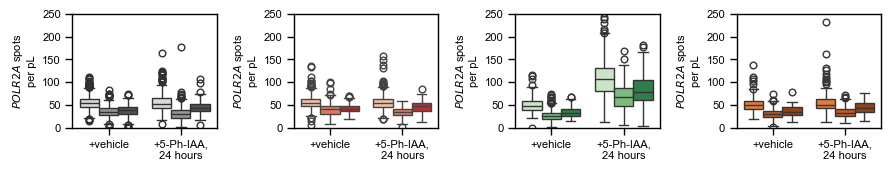

In [65]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 4, figsize = (9,1.8))

Veh_5PhIAA = PlotForTalk.query('TREATMENT in ["Vehicle", "5PhIAA"]')

h = sns.boxplot(Veh_5PhIAA.query('CELL == "OsTIRF74G"'),
            x = 'TREATMENT', order = ["Vehicle", "5PhIAA"],
            y = 'Spots_633_per_pL',
            hue = 'REPLICATE', dodge = True, palette = 'Greys',
            ax = a[0])
h.legend().remove()

h = sns.boxplot(Veh_5PhIAA.query('CELL == "mChPOLR2A"'),
            x = 'TREATMENT', order = ["Vehicle", "5PhIAA"],
            y = 'Spots_633_per_pL',
            hue = 'REPLICATE', dodge = True, palette = 'Reds',
            ax = a[1])
h.legend().remove()

h = sns.boxplot(Veh_5PhIAA.query('CELL == "mACPOLR2A"'),
            x = 'TREATMENT', order = ["Vehicle", "5PhIAA"],
            y = 'Spots_633_per_pL',
            hue = 'REPLICATE', dodge = True, palette = 'Greens',
            ax = a[2])
h.legend().remove()

h = sns.boxplot(Veh_5PhIAA.query('CELL == "mAC/mChPOLR2A"'),
            x = 'TREATMENT', order = ["Vehicle", "5PhIAA"],
            y = 'Spots_633_per_pL',
            hue = 'REPLICATE', dodge = True, palette = sns.color_palette([sns.color_palette('Oranges')[3],sns.color_palette('Oranges')[4],sns.color_palette('Oranges')[5]]),
            ax = a[3])
h.legend().remove()

titles = ['OsTIRF74G', 'mCh-POLR2A', 'mAC-POLR2A', 'mAC-/mCh-POLR2A']

for i in range(4):
    a[i].set_ylim(0,250)
    a[i].set_xlabel('')
    a[i].set_xticks([0,1], labels = ['+vehicle','+5-Ph-IAA,\n24 hours'])
    a[i].set_ylabel('$POLR2A$ spots\nper pL', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)

plt.tight_layout()

plt.savefig('mACmChPOLR2A_POLR2AsmFISH_Veh5PhIAA_3repeats.svg')

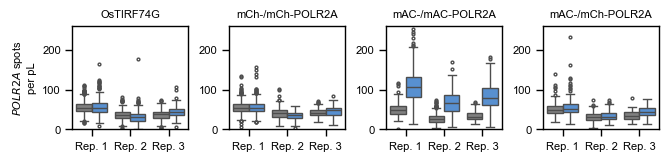

In [98]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 4, figsize = (6.6, 1.5), layout = 'constrained')

Veh_5PhIAA = PlotForTalk.query('TREATMENT in ["Vehicle", "5PhIAA"]')

pal = sns.color_palette(['grey', 'xkcd:dark sky blue'])

h = sns.boxplot(Veh_5PhIAA.query('CELL == "OsTIRF74G"'),
                x = 'REPLICATE',
                y = 'Spots_633_per_pL',
                hue = 'TREATMENT', hue_order = ["Vehicle", "5PhIAA"], 
                dodge = True, palette = pal, fliersize = 2,
                ax = a[0])
h.legend().remove()

h = sns.boxplot(Veh_5PhIAA.query('CELL == "mChPOLR2A"'),
                x = 'REPLICATE',
                y = 'Spots_633_per_pL',
                hue = 'TREATMENT', hue_order = ["Vehicle", "5PhIAA"], 
                dodge = True, palette = pal, fliersize = 2,
                ax = a[1])
h.legend().remove()

h = sns.boxplot(Veh_5PhIAA.query('CELL == "mACPOLR2A"'),
                x = 'REPLICATE',
                y = 'Spots_633_per_pL',
                hue = 'TREATMENT', hue_order = ["Vehicle", "5PhIAA"], 
                dodge = True, palette = pal, fliersize = 2,
                ax = a[2])
h.legend().remove()

h = sns.boxplot(Veh_5PhIAA.query('CELL == "mAC/mChPOLR2A"'),
                x = 'REPLICATE',
                y = 'Spots_633_per_pL',
                hue = 'TREATMENT', hue_order = ["Vehicle", "5PhIAA"], 
                dodge = True, palette = pal, fliersize = 2,
                ax = a[3])
h.legend().remove()

titles = ['OsTIRF74G', 'mCh-/mCh-POLR2A', 'mAC-/mAC-POLR2A', 'mAC-/mCh-POLR2A']

for i in range(4):
    a[i].set_ylim(0,260)
    a[i].set_xlabel('')
    a[i].set_xticks([0,1,2], labels = ['Rep. 1', 'Rep. 2', 'Rep. 3'])
    a[i].set_ylabel('$POLR2A$ spots\nper pL', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].set_title(titles[i], fontsize = 8)
    
for i in [1,2,3]:
    a[i].set_ylabel('')

plt.savefig('mACmChPOLR2A_POLR2AsmFISH_Veh5PhIAA_3repeats_byrepeat.svg')

In [76]:
Veh_5PhIAA_ByReplicate = Veh_5PhIAA[['CELL', 'TREATMENT', 'REPLICATE', 'Spots_633_per_pL']].groupby(['CELL', 'TREATMENT', 'REPLICATE']).mean().reset_index()

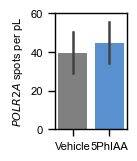

In [91]:
f, a = plt.subplots(ncols = 1, figsize = (3, 1.5), layout = 'constrained')

pal = sns.color_palette(['grey', 'xkcd:dark sky blue'])

sns.barplot(Veh_5PhIAA_ByReplicate.query('CELL == "mAC/mChPOLR2A"'),
            x = 'TREATMENT', order = ['Vehicle', '5PhIAA'],
            y = 'Spots_633_per_pL',
            palette = pal, hue = 'TREATMENT', hue_order = ['Vehicle', '5PhIAA'],
            errorbar = 'sd')

a.tick_params(axis = 'both', labelsize = 8)

a.set_box_aspect(1.6)

a.set_ylim(0,60)
a.set_yticks([0, 20, 40, 60])
a.set_ylabel('$POLR2A$ spots per pL', fontsize = 8)
a.set_xlabel('')

plt.savefig('mACmCherryPOLR2A_Vehicle_5PhIAA_spotsperpl.svg')

## comparing nuclear volume to cell volume

In [67]:
QuantificationMultiple.CELL.unique()

array(['OsTIRF74G', 'mChPOLR2A', 'mAC/mChPOLR2A', 'mACPOLR2A'],
      dtype=object)

In [68]:
QuantificationMultiple.query('CELL == "HCT116 OsTIRF74G"')

,WELL,FOV,LABEL,CellVolume,Spots_565,Spots_633,NucleiVolume,Nuclei561Mean,Nuclei405Mean,EXPERIMENT,ATTO565_PROBE,ATTO633_PROBE,CELL,TREATMENT,CELL_TYPE,REPLICATE


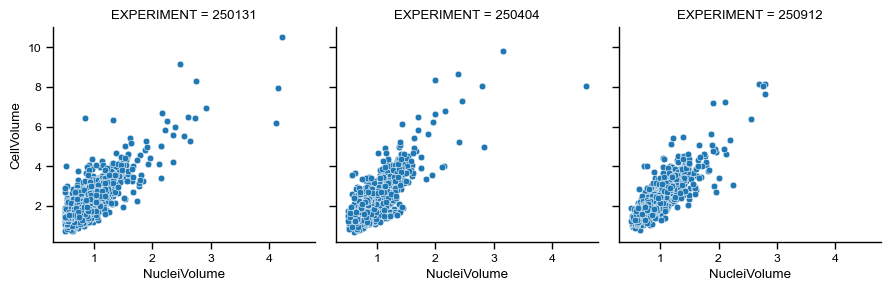

In [69]:
g = sns.FacetGrid(QuantificationMultiple.query('CELL == "OsTIRF74G"'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.scatterplot,
                x = 'NucleiVolume',
                y = 'CellVolume')

In [70]:
QuantificationMultiple['CytoVolume'] = QuantificationMultiple['CellVolume'] - QuantificationMultiple['NucleiVolume']

In [71]:
QuantificationMultiple['NucleiCytoVolumeRatio'] = QuantificationMultiple['NucleiVolume'] / QuantificationMultiple['CytoVolume']

Text(0, 0.5, 'Nucleus to cytoplasm\nvolume ratio')

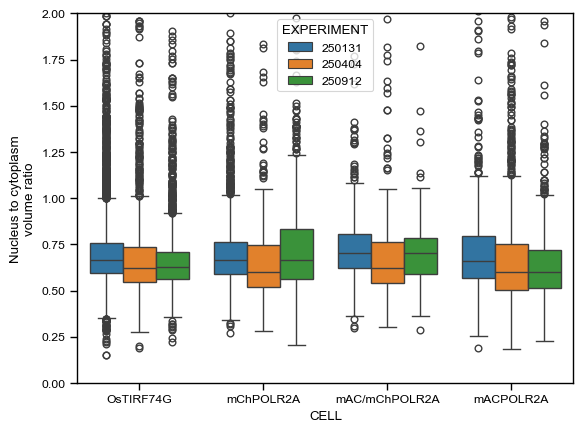

In [72]:
sns.boxplot(QuantificationMultiple,
            x = 'CELL',
            y = 'NucleiCytoVolumeRatio',
            hue = 'EXPERIMENT', dodge = True)

plt.ylim(0,2)
plt.ylabel('Nucleus to cytoplasm\nvolume ratio')

In [73]:
QuantificationMultiple['NucleiCytoVolumeRatio'].mean()

0.7327220686767338

## comparing nuclear area to nuclear volumes